In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import os
import xarray as xr
import numpy as np
from natsort import natsorted
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [7]:
import sys
original_path = os.getcwd()  
os.chdir(original_path)
function_path = './functions/'
sys.path.append(function_path)
from smoothing_function import *
from model_analysis_function import *
from analysis_function import *
from Plot_function import *
from ar6_area_weighted_cont_global import *
# from obs_function import *

### Constrained warming relative to current year 2025

In [37]:
path = './saved_data/'

def load_xr_pickle(filename):
    with open(filename, "rb") as f:
        return pickle.load(f)
        
post_smooth_ALL_ref2025 = load_xr_pickle(path + '4.0_constrained_46reg_4schemes_smoothed_warming_ref2025_1850-2100.pkl'
)
post_smooth_ALL_ref1850 = load_xr_pickle(path + '4.0_constrained_46reg_4schemes_smoothed_warming_ref1850_1850-2100.pkl'
)


prior_smooth_ALL_ref2025 = load_xr_pickle(path + '2.2_prior_46reg_smoothed_warming_ref2025_1850-2100.pkl'
)
prior_smooth_ALL_ref1850 = load_xr_pickle(path + '2.3_prior_46reg_smoothed_warming_ref1850_1850-2100.pkl'
)


post_smooth_ALL_ref2025 = xr.concat([post_smooth_ALL_ref2025, prior_smooth_ALL_ref2025.assign_coords(scheme = 'prior')], dim = 'scheme')

post_smooth_ALL_ref1850 = xr.concat([post_smooth_ALL_ref1850, prior_smooth_ALL_ref1850.assign_coords(scheme = 'prior')], dim = 'scheme')

In [38]:
gsat_15_post = 2029
gsat_2_post = 2042

post_warming_15_ref2025 = post_smooth_ALL_ref2025.sel(year = slice(gsat_15_post-5, gsat_15_post+5)).mean('year').squeeze()
post_warming_2_ref2025 = post_smooth_ALL_ref2025.sel(year = slice(gsat_2_post-5, gsat_2_post+5)).mean('year').squeeze()

post_warming_15_ref2025

<xarray.DataArray 'post_mean_5_95_smooth' (scheme: 5, region: 47, quantile: 3)> Size: 6kB
array([[[ 0.2437131 , -1.31206812,  1.87867699],
        [ 0.28485156, -0.67385332,  1.37182712],
        [ 0.32198316, -1.03440734,  1.69602034],
        [ 0.17072868, -0.25060346,  0.63892858],
        [ 0.16951686, -0.2919784 ,  0.63860486],
        [ 0.18547588, -0.21075069,  0.57791781],
        [ 0.17625145, -0.11789826,  0.46307255],
        [ 0.13233507, -0.09729587,  0.40979413],
        [ 0.11649004, -0.08350633,  0.3373082 ],
        [ 0.13153889, -0.20800877,  0.52570292],
        [ 0.20005663, -0.49288714,  0.91275129],
        [ 0.16065266, -0.22163734,  0.50784688],
        [ 0.2125146 , -0.42839799,  1.01423794],
        [ 0.09222152, -0.19749695,  0.39961215],
        [ 0.10524385, -0.23063475,  0.38788141],
        [ 0.06579849, -0.17452149,  0.34849519],
        [ 0.17854782, -0.46213729,  0.74455952],
        [ 0.24287393, -0.25644034,  0.69229889],
        [ 0.26320463, -0.33503673,  0.81983476],
        [ 0.19729491, -0.14791239,  0.57251215],
...
        [ 0.13078372, -0.22636184,  0.55895096],
        [ 0.36590099, -1.23723084,  1.94687925],
        [ 0.26681389, -0.71773093,  1.21429402],
        [ 0.2631828 , -0.68779188,  1.29532801],
        [ 0.26265629, -0.84715852,  1.43412602],
        [ 0.22172045, -0.56863969,  1.02896157],
        [ 0.22850179, -0.58443983,  0.97725037],
        [ 0.21221313, -1.04304898,  1.43655451],
        [ 0.18378461, -0.48767771,  0.8914922 ],
        [ 0.21303189, -0.45409825,  0.90304876],
        [ 0.16807189, -0.42580706,  0.77897644],
        [ 0.13045821, -0.26646696,  0.55697474],
        [ 0.13774568, -0.2457915 ,  0.60897082],
        [ 0.17783578, -0.42278091,  0.74551418],
        [ 0.15985303, -0.31882177,  0.66058179],
        [ 0.12094386, -0.31125698,  0.56000698],
        [ 0.11788002, -0.30210003,  0.51004381],
        [ 0.16878737, -0.56877236,  0.93584186],
        [ 0.16480835, -0.92370545,  1.17200874],
        [ 0.19118887, -0.47771196,  0.85232667]]])
Coordinates:
  * region       (region) int64 376B 0 1 2 3 4 5 6 7 ... 39 40 41 42 43 44 45 46
    forcing      <U3 12B 'ALL'
  * quantile     (quantile) <U4 48B 'mean' '5th' '95th'
  * scheme       (scheme) object 40B 'single_region' ... 'prior'
    abbrevs      (scheme, region) object 2kB 'GIC' 'NWN' 'NEN' ... 'WAN' 'LSAT'
    names        (scheme, region) object 2kB 'Greenland/Iceland' ... 'Global ...
    realization  int64 8B 100

In [39]:
current_yr = 2025
post_warming_current_year = post_smooth_ALL_ref1850.sel(year = current_yr, quantile = 'mean').squeeze()

percent_nowaday_15 = (post_warming_current_year / (post_warming_current_year + post_warming_15_ref2025)) * 100
percent_nowaday_2 = (post_warming_current_year / (post_warming_current_year + post_warming_2_ref2025)) * 100


## switch 5, 95th, cause it is on denorminator
percent_nowaday_15 = percent_nowaday_15.rename({'quantile': 'quantile'})
percent_nowaday_15 = percent_nowaday_15.assign_coords(
    quantile=['95th' if q == '5th' else '5th' if q == '95th' else q for q in percent_nowaday_15['quantile'].values]
)

percent_nowaday_2 = percent_nowaday_2.rename({'quantile': 'quantile'})
percent_nowaday_2 = percent_nowaday_2.assign_coords(
    quantile=['95th' if q == '5th' else '5th' if q == '95th' else q for q in percent_nowaday_2['quantile'].values]
)
percent_nowaday_15

<xarray.DataArray 'post_mean_5_95_smooth' (scheme: 5, region: 47, quantile: 3)> Size: 6kB
array([[[ 91.85954503, 191.23813651,  59.41343486],
        [ 91.38317083, 128.71060616,  68.77053998],
        [ 90.75482212, 148.64768108,  65.07912218],
        [ 91.52083168, 115.73969129,  74.25447425],
        [ 92.00006923, 117.61576139,  75.3250269 ],
        [ 91.43166925, 111.91731466,  77.39956795],
        [ 90.82042732, 107.2513057 ,  79.01668594],
        [ 91.21727503, 107.61829423,  77.03236843],
        [ 91.25193474, 107.3794081 ,  78.27220704],
        [ 91.49849937, 117.22361055,  72.92155308],
        [ 90.1052914 , 137.08955541,  66.62150926],
        [ 91.66501977, 114.34396401,  77.67357839],
        [ 89.92082044, 129.19159605,  65.14855484],
        [ 91.58871408, 124.48257819,  71.53339413],
        [ 92.62335795, 121.14287673,  77.30832015],
        [ 93.6386701 , 121.97917411,  73.53967079],
        [ 91.77028809, 130.22745285,  72.78221951],
        [ 90.97261507, 111.70373296,  77.9511265 ],
        [ 91.05885856, 114.28419751,  76.57867675],
        [ 91.03826319, 107.968052  ,  77.78155468],
...
        [ 90.65186345, 121.72608555,  69.40946762],
        [ 91.18314992, 148.5781487 ,  66.02896462],
        [ 90.28615113, 140.72943394,  67.12986953],
        [ 90.17240564, 139.82527683,  65.08684765],
        [ 90.70614859, 149.35915679,  64.12531899],
        [ 90.37656184, 137.56862039,  66.92722332],
        [ 90.28475173, 137.97407301,  68.48331623],
        [ 90.51028755, 206.32702924,  58.48810757],
        [ 88.49932963, 152.63249153,  61.33598676],
        [ 91.09791478, 126.31041398,  70.70945821],
        [ 88.5248722 , 148.89930374,  62.46922193],
        [ 90.69456377, 126.51328813,  69.53881151],
        [ 90.85306721, 121.89903889,  69.19952025],
        [ 90.59678003, 132.75833793,  69.68099549],
        [ 90.36287018, 127.01775066,  69.40970804],
        [ 90.49933199, 137.01902071,  67.29058852],
        [ 90.99851233, 133.95979296,  70.02784185],
        [ 90.61444217, 153.61661667,  63.52102137],
        [ 91.55282965, 207.09202895,  60.38166634],
        [ 90.82404121, 133.76810885,  68.94670808]]])
Coordinates:
  * region       (region) int64 376B 0 1 2 3 4 5 6 7 ... 39 40 41 42 43 44 45 46
    year         int64 8B 2025
    forcing      <U3 12B 'ALL'
  * scheme       (scheme) object 40B 'single_region' ... 'prior'
    abbrevs      (scheme, region) object 2kB 'GIC' 'NWN' 'NEN' ... 'WAN' 'LSAT'
    names        (scheme, region) object 2kB 'Greenland/Iceland' ... 'Global ...
    realization  int64 8B 100
  * quantile     (quantile) <U4 48B 'mean' '95th' '5th'

### Map plotting

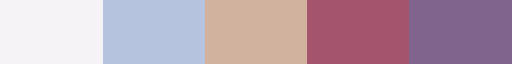

In [40]:
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap


cmap_percent = modify_cmap('twilight', start=0.0, end=0.9, gamma=1.0, white_strength=0.7)   # example: different color map
bounds2 = np.arange(50, 110, 10)  # example levels
norm2 = mcolors.BoundaryNorm(boundaries=bounds2, ncolors=256, extend='neither')

n_colors = len(bounds2) - 1  # = 5

# Get discrete colors from the colormap
colors_n = [cmap_percent(i / (n_colors - 1)) for i in range(n_colors)]

# Swap the 5th color into 3rd position
# Note: Python is 0-based -> 5th = index 4, 3rd = index 2
colors_n[2], colors_n[4] = colors_n[4], colors_n[2]

# Create a new colormap with the modified order
cmap_percent = mcolors.ListedColormap(colors_n)

# Recreate the norm
norm2 = mcolors.BoundaryNorm(boundaries=bounds2, ncolors=cmap_percent.N, extend='neither')

cmap_percent

In [41]:
def plot_panel(ax, data, title, cmap, norm, decimals,
               global_value=None, unit="°C"):
    
    ax.set_global()
    norm0 = plot_ar6_region_data_on_ax_new(
        ax, data, cmap=cmap, norm=norm, decimals=decimals
    )

    # ---- Add title ----
    ax.set_title(title, fontsize=22, fontweight='bold', loc='left')

    # ---- Add the global value with a unit ----
    if global_value is not None:
        ax.text(
            0.06, 0.5,
            f"Global: {global_value:.1f}{unit}",   # unit inserted here
            transform=ax.transAxes,
            fontsize=14,
            fontweight='bold',
            color='black',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=4)
        )

    return norm0


In [42]:
percent_nowaday_15.isel(scheme = scheme_id)['scheme'].values

array('continent_region', dtype='<U16')

/var/folders/jt/kr53pz_j4x3d_32xbfb7pkd87_b0mf/T/ipykernel_81654/1462040346.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


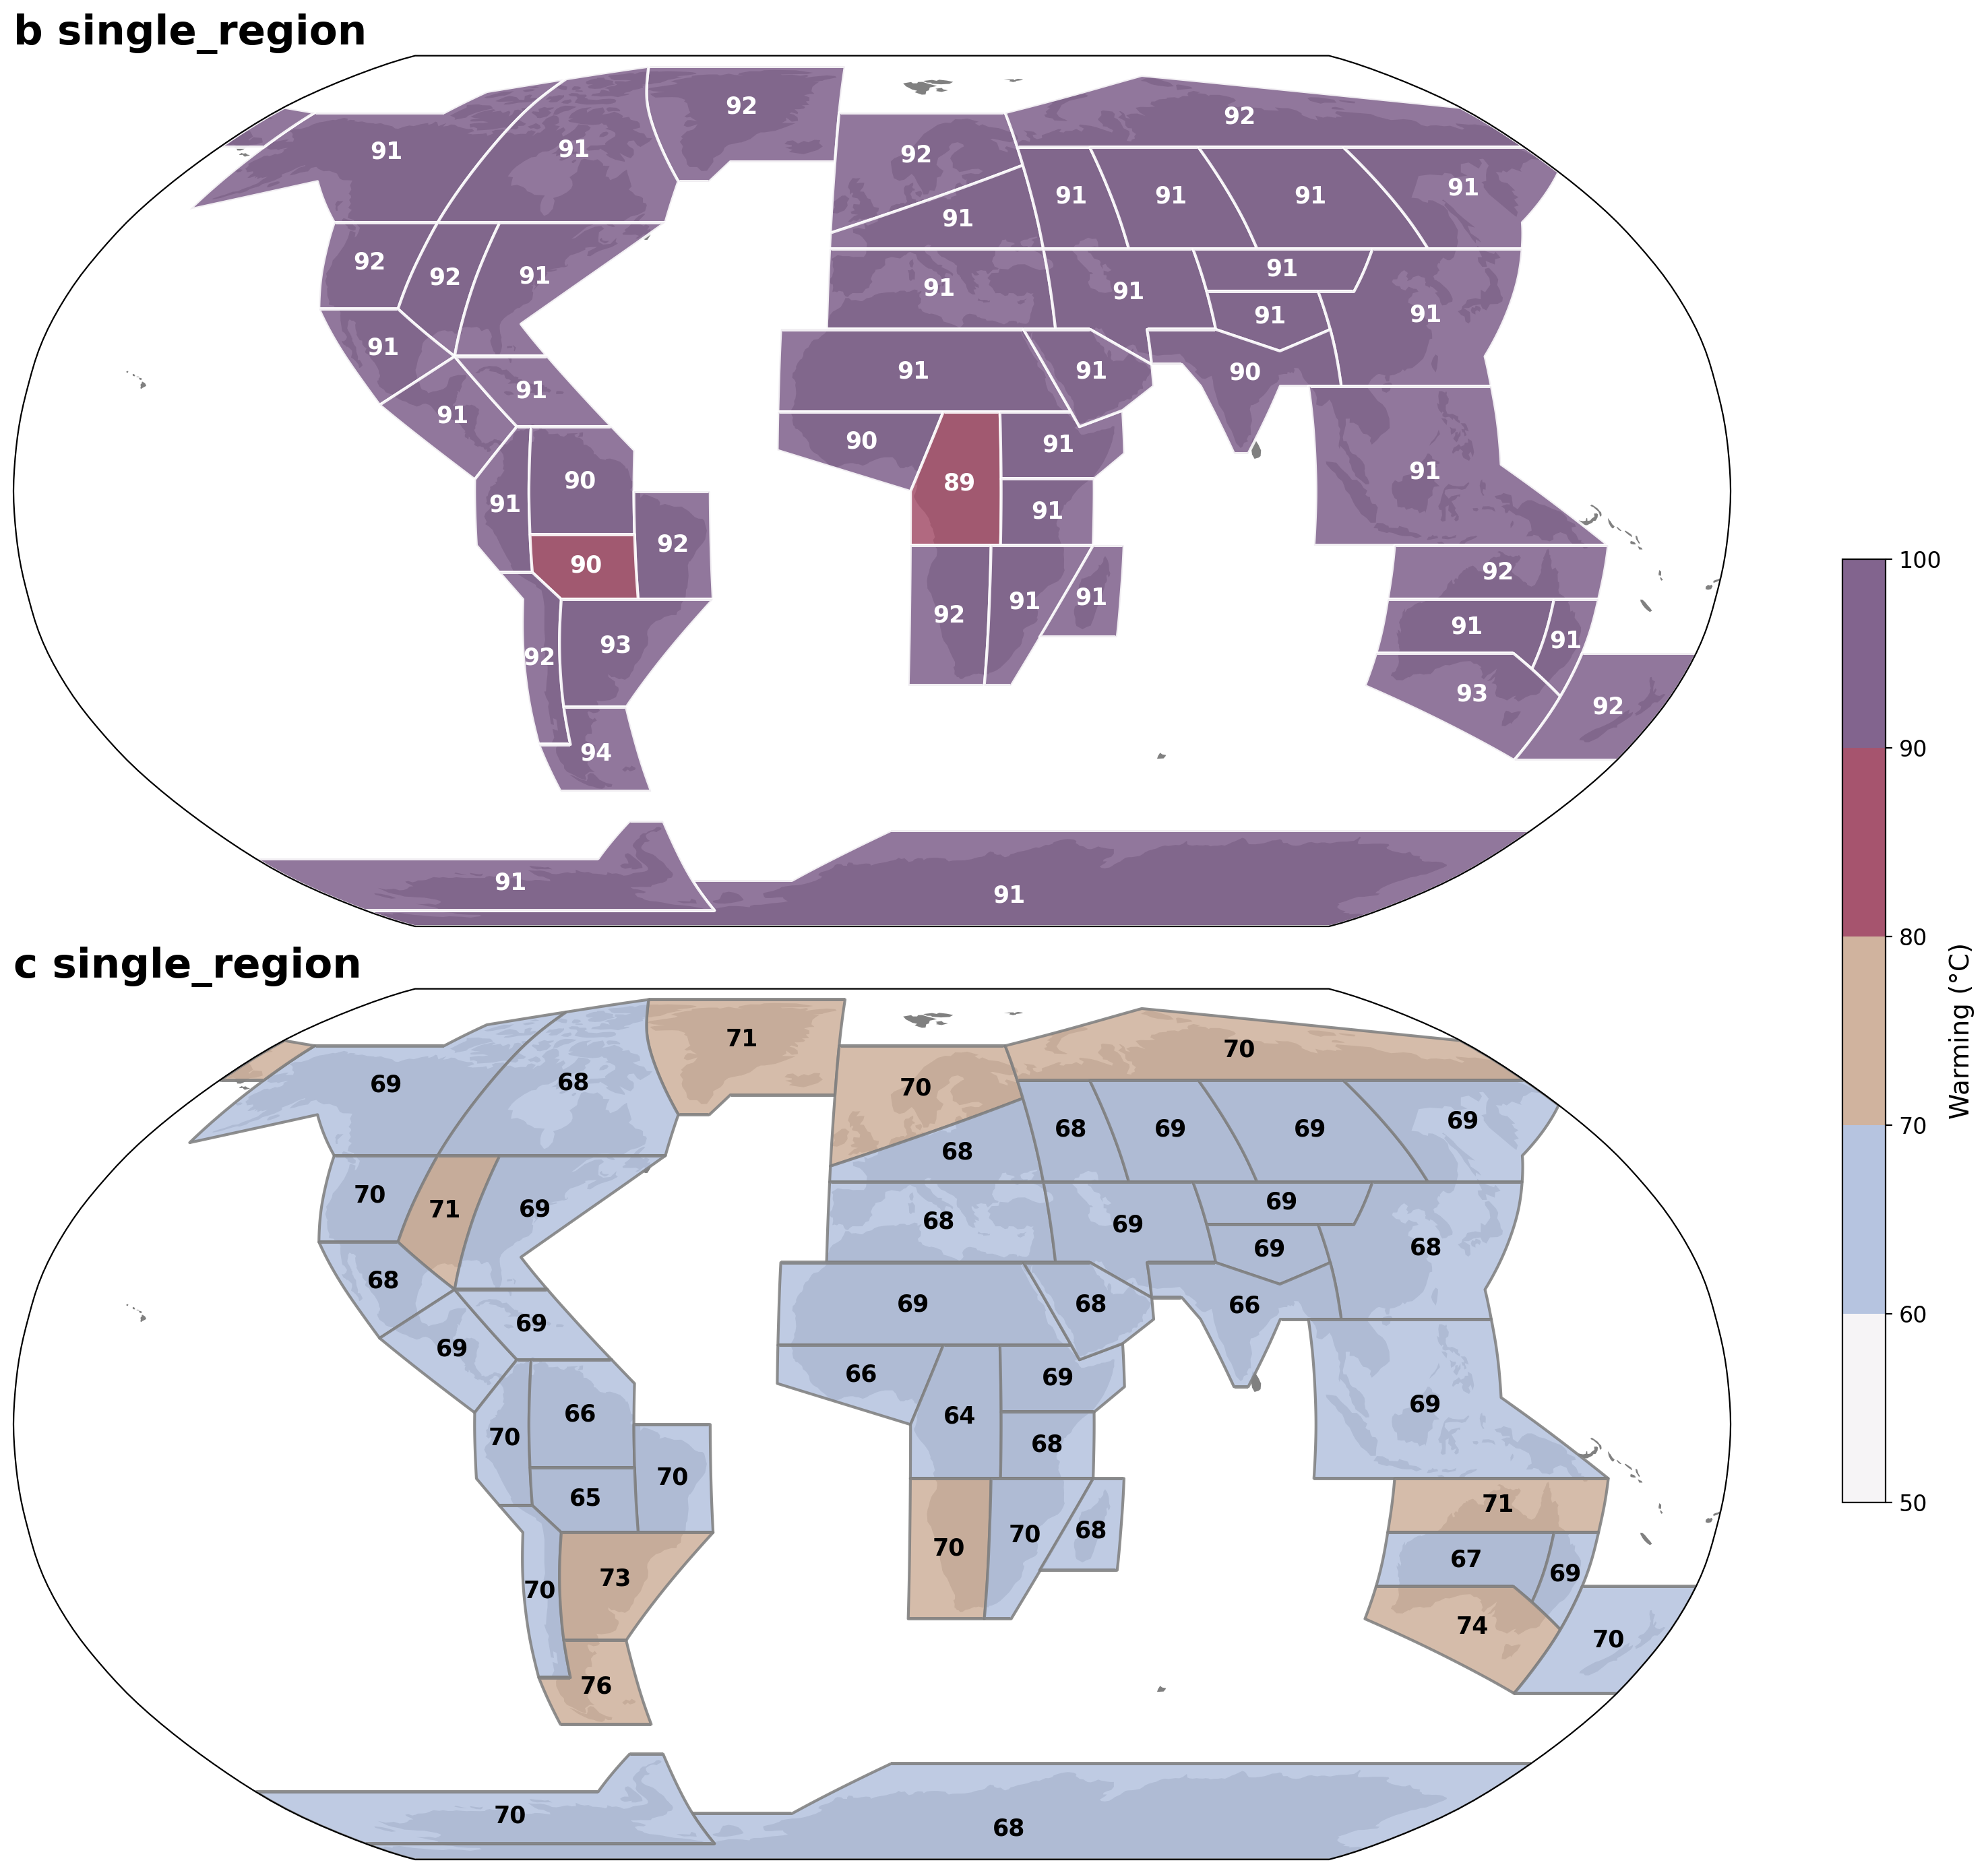

/var/folders/jt/kr53pz_j4x3d_32xbfb7pkd87_b0mf/T/ipykernel_81654/1462040346.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


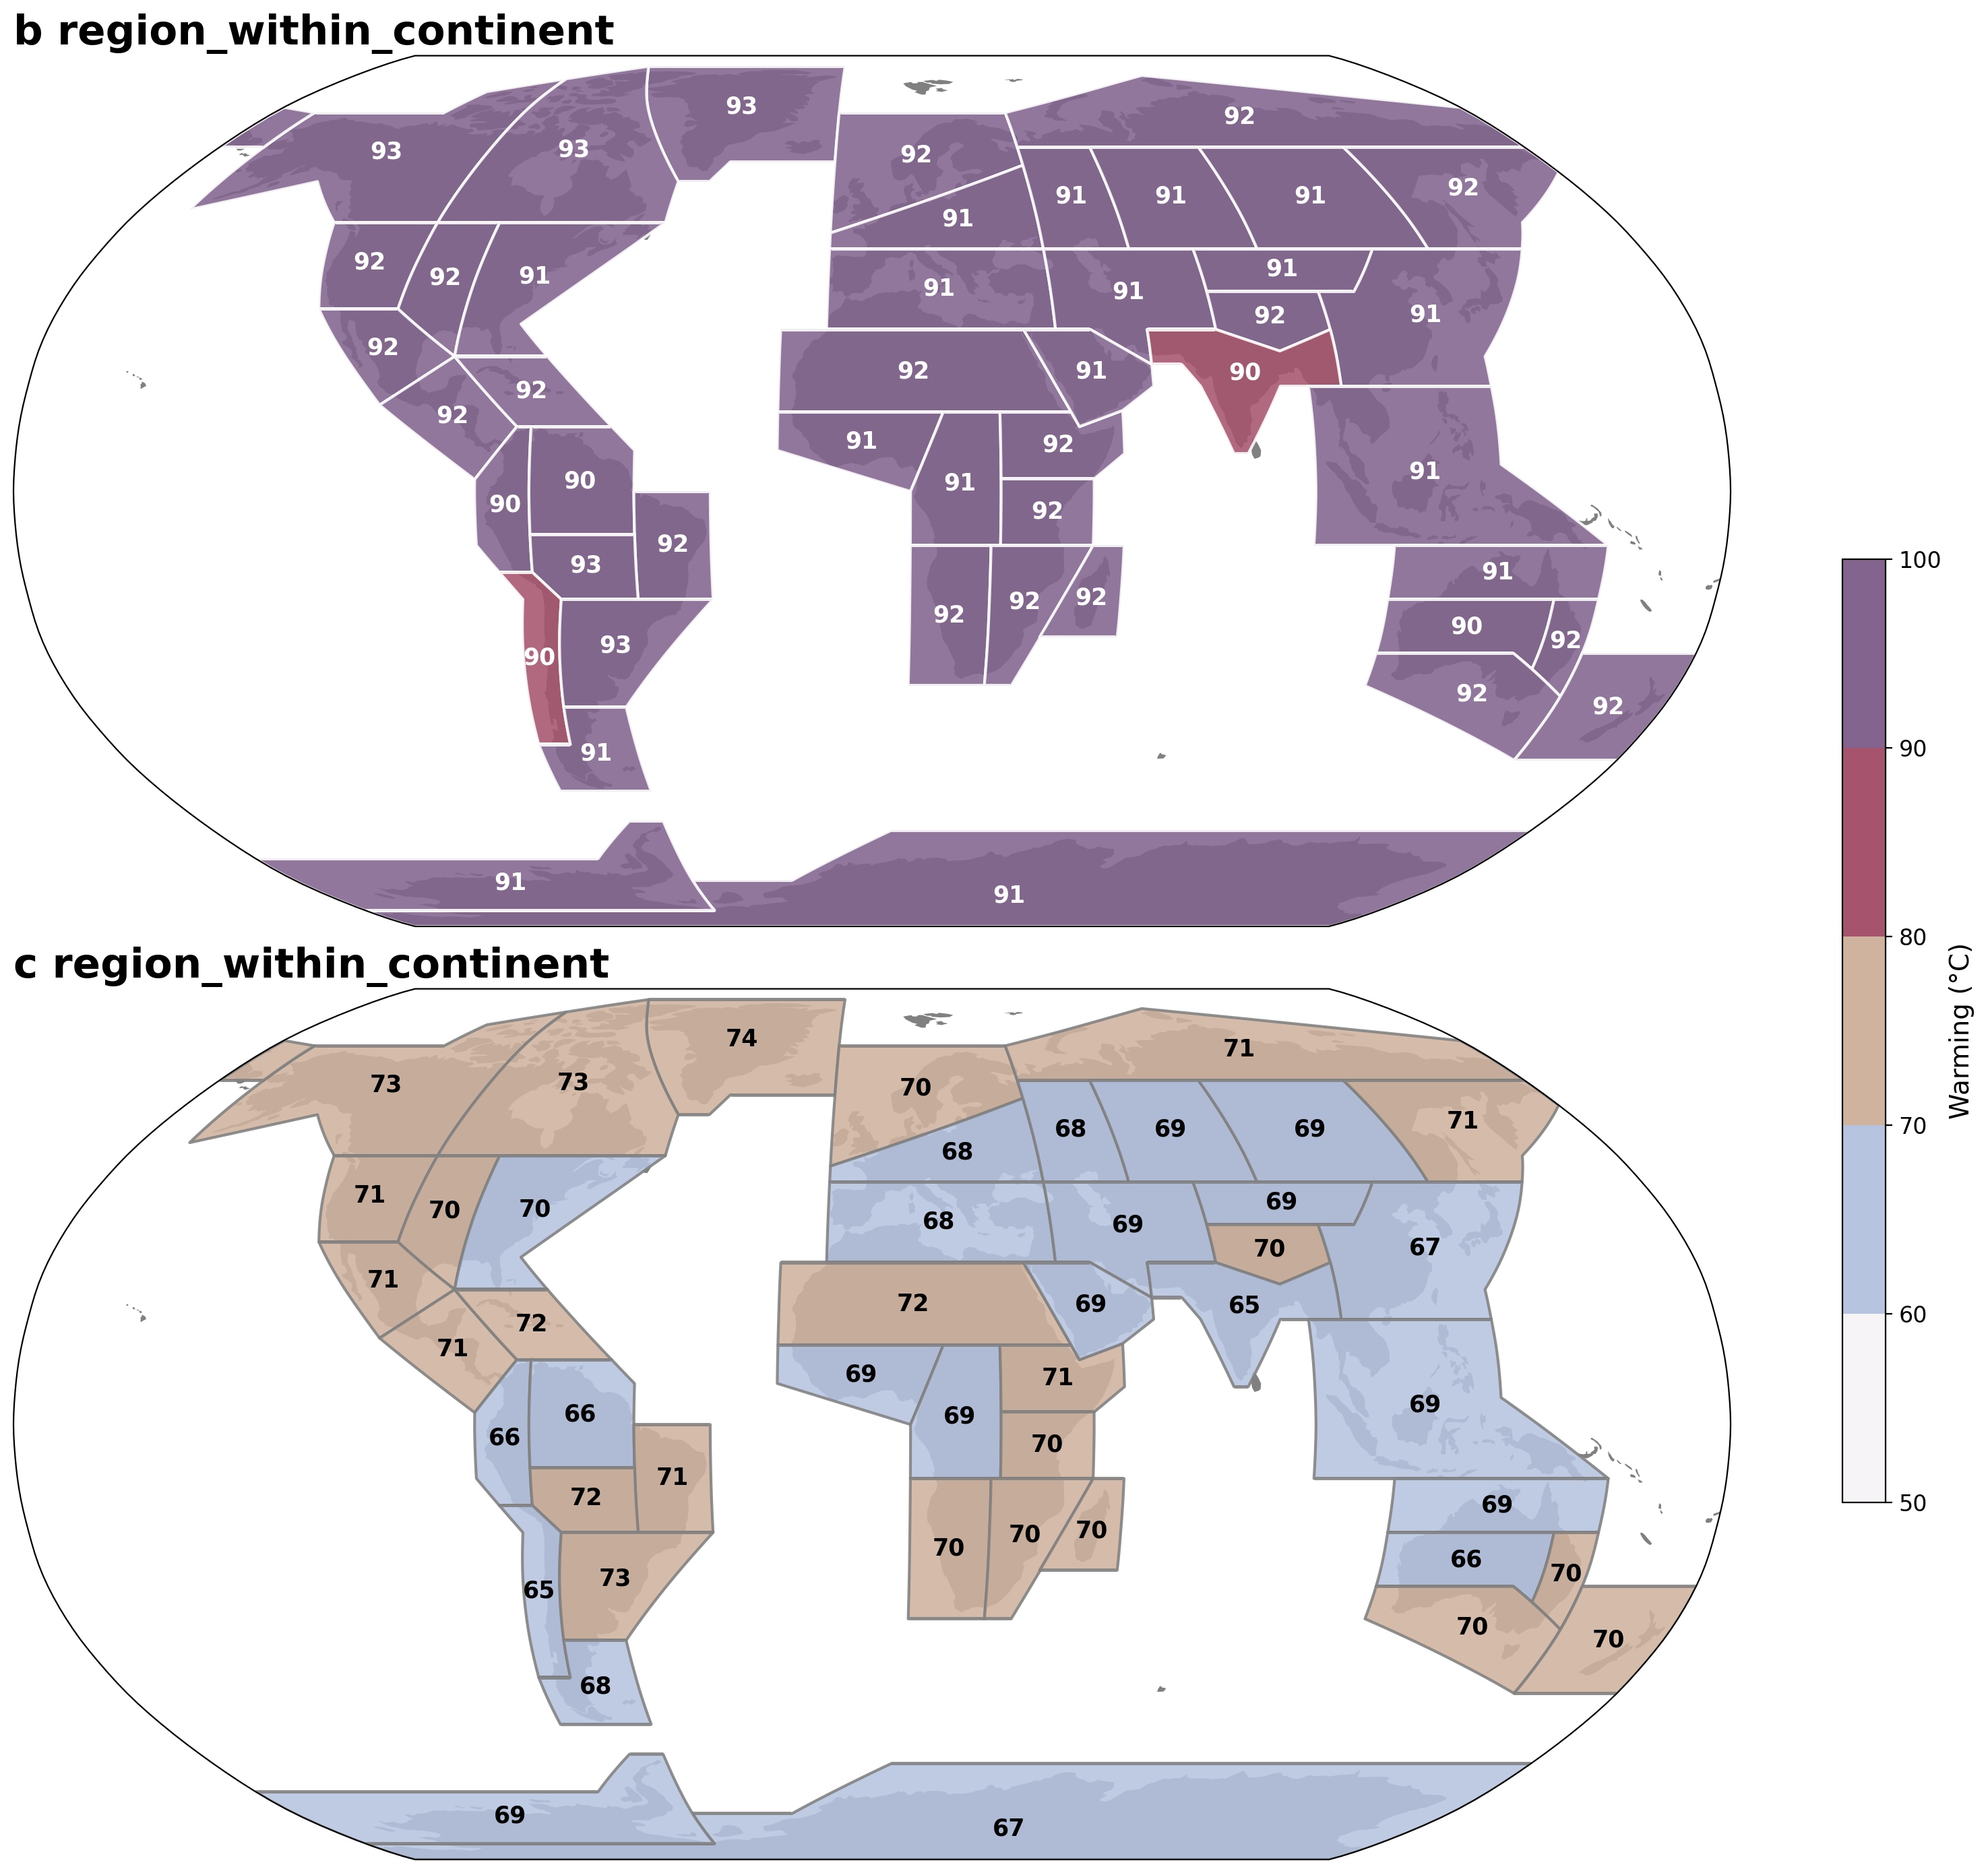

/var/folders/jt/kr53pz_j4x3d_32xbfb7pkd87_b0mf/T/ipykernel_81654/1462040346.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


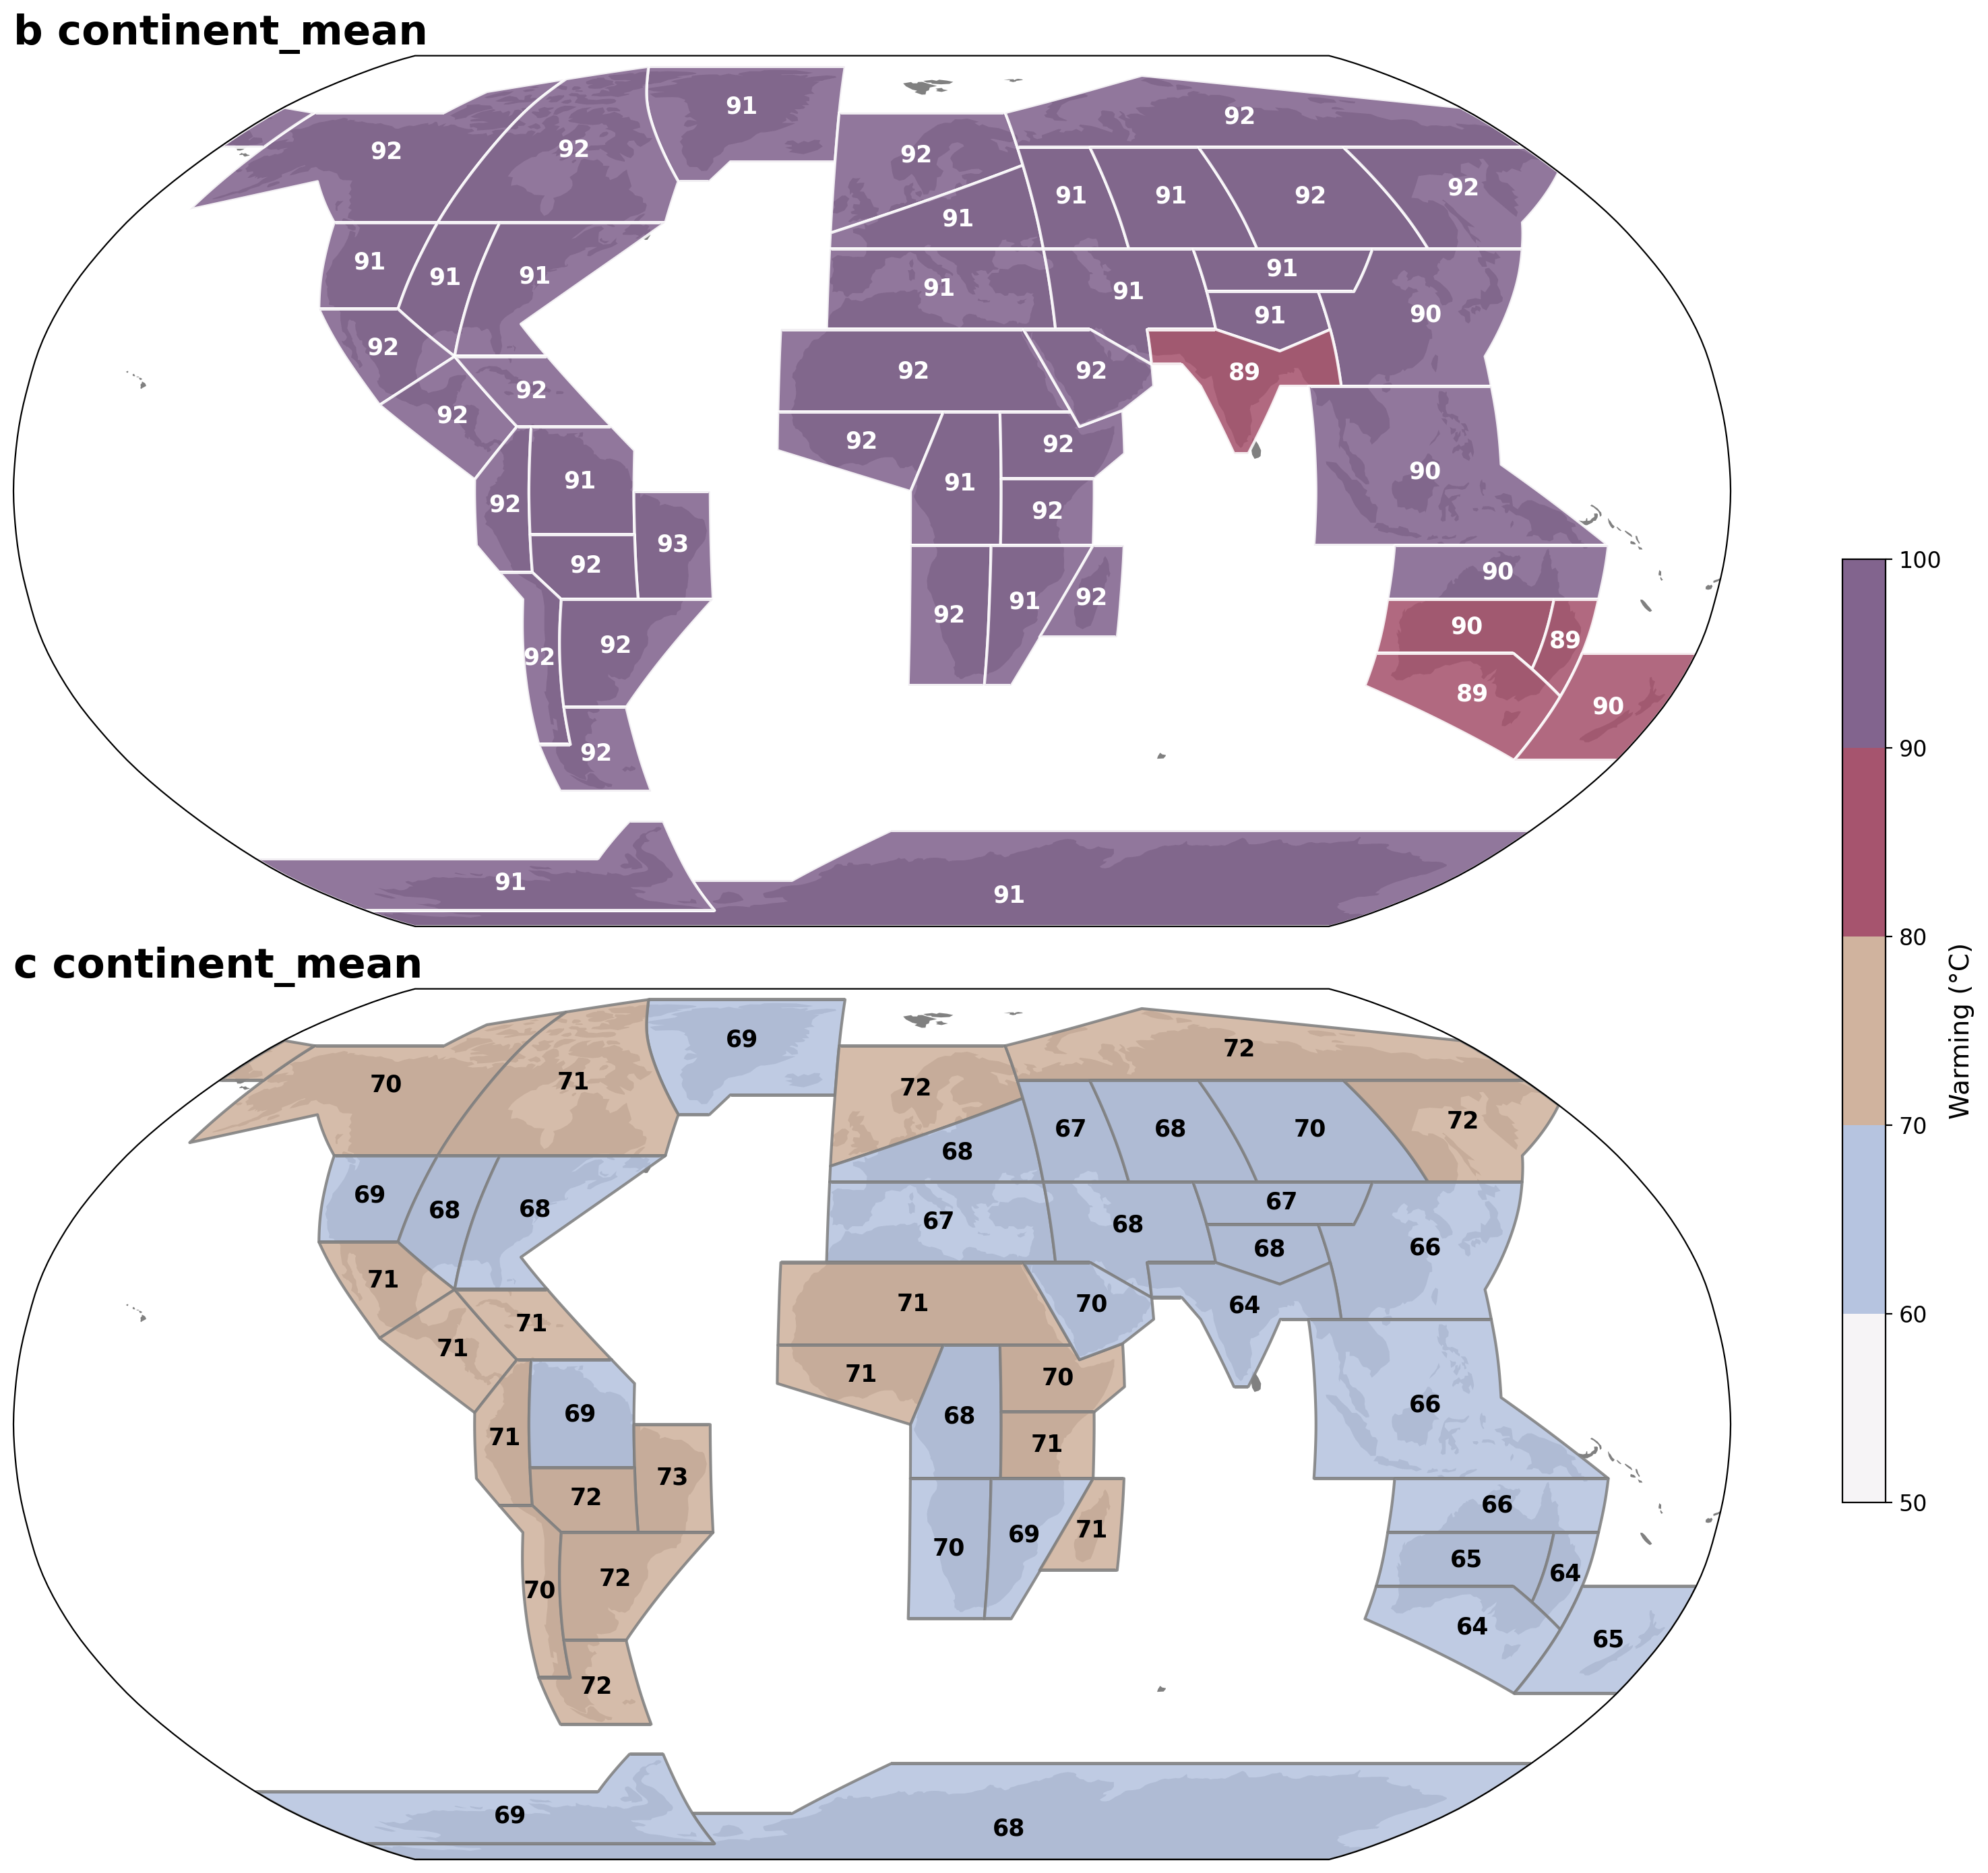

/var/folders/jt/kr53pz_j4x3d_32xbfb7pkd87_b0mf/T/ipykernel_81654/1462040346.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


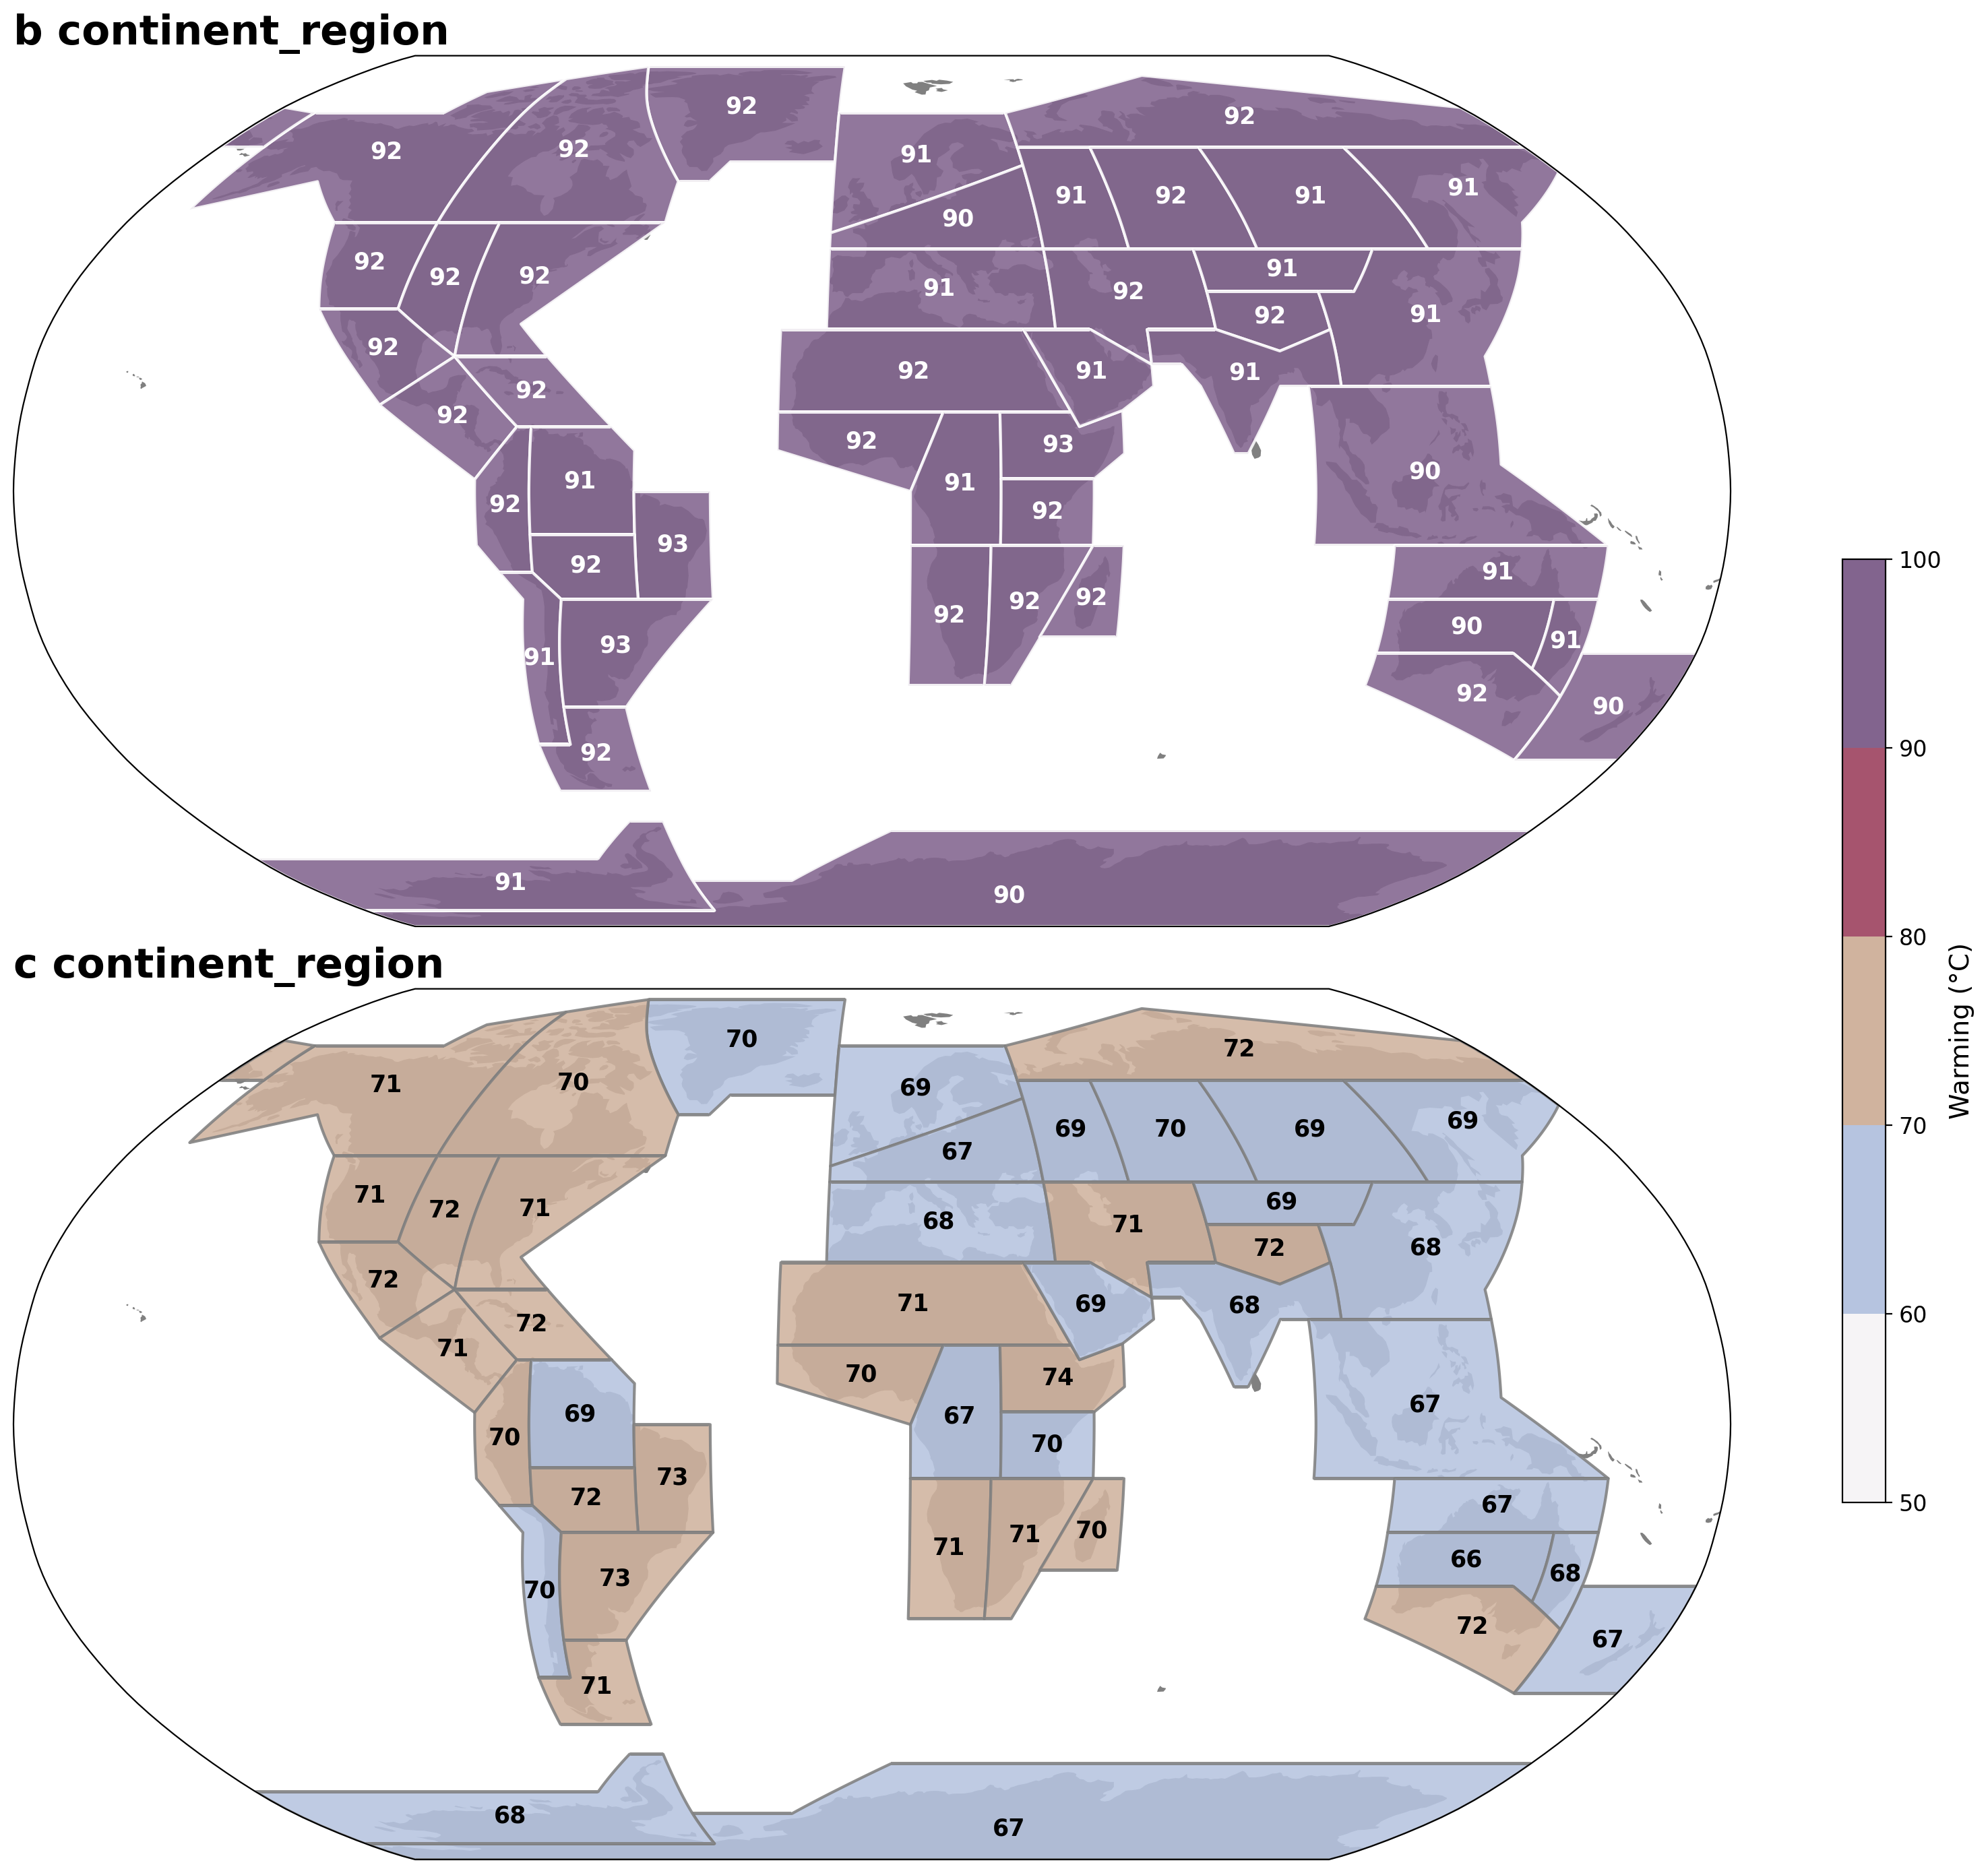

/var/folders/jt/kr53pz_j4x3d_32xbfb7pkd87_b0mf/T/ipykernel_81654/1462040346.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


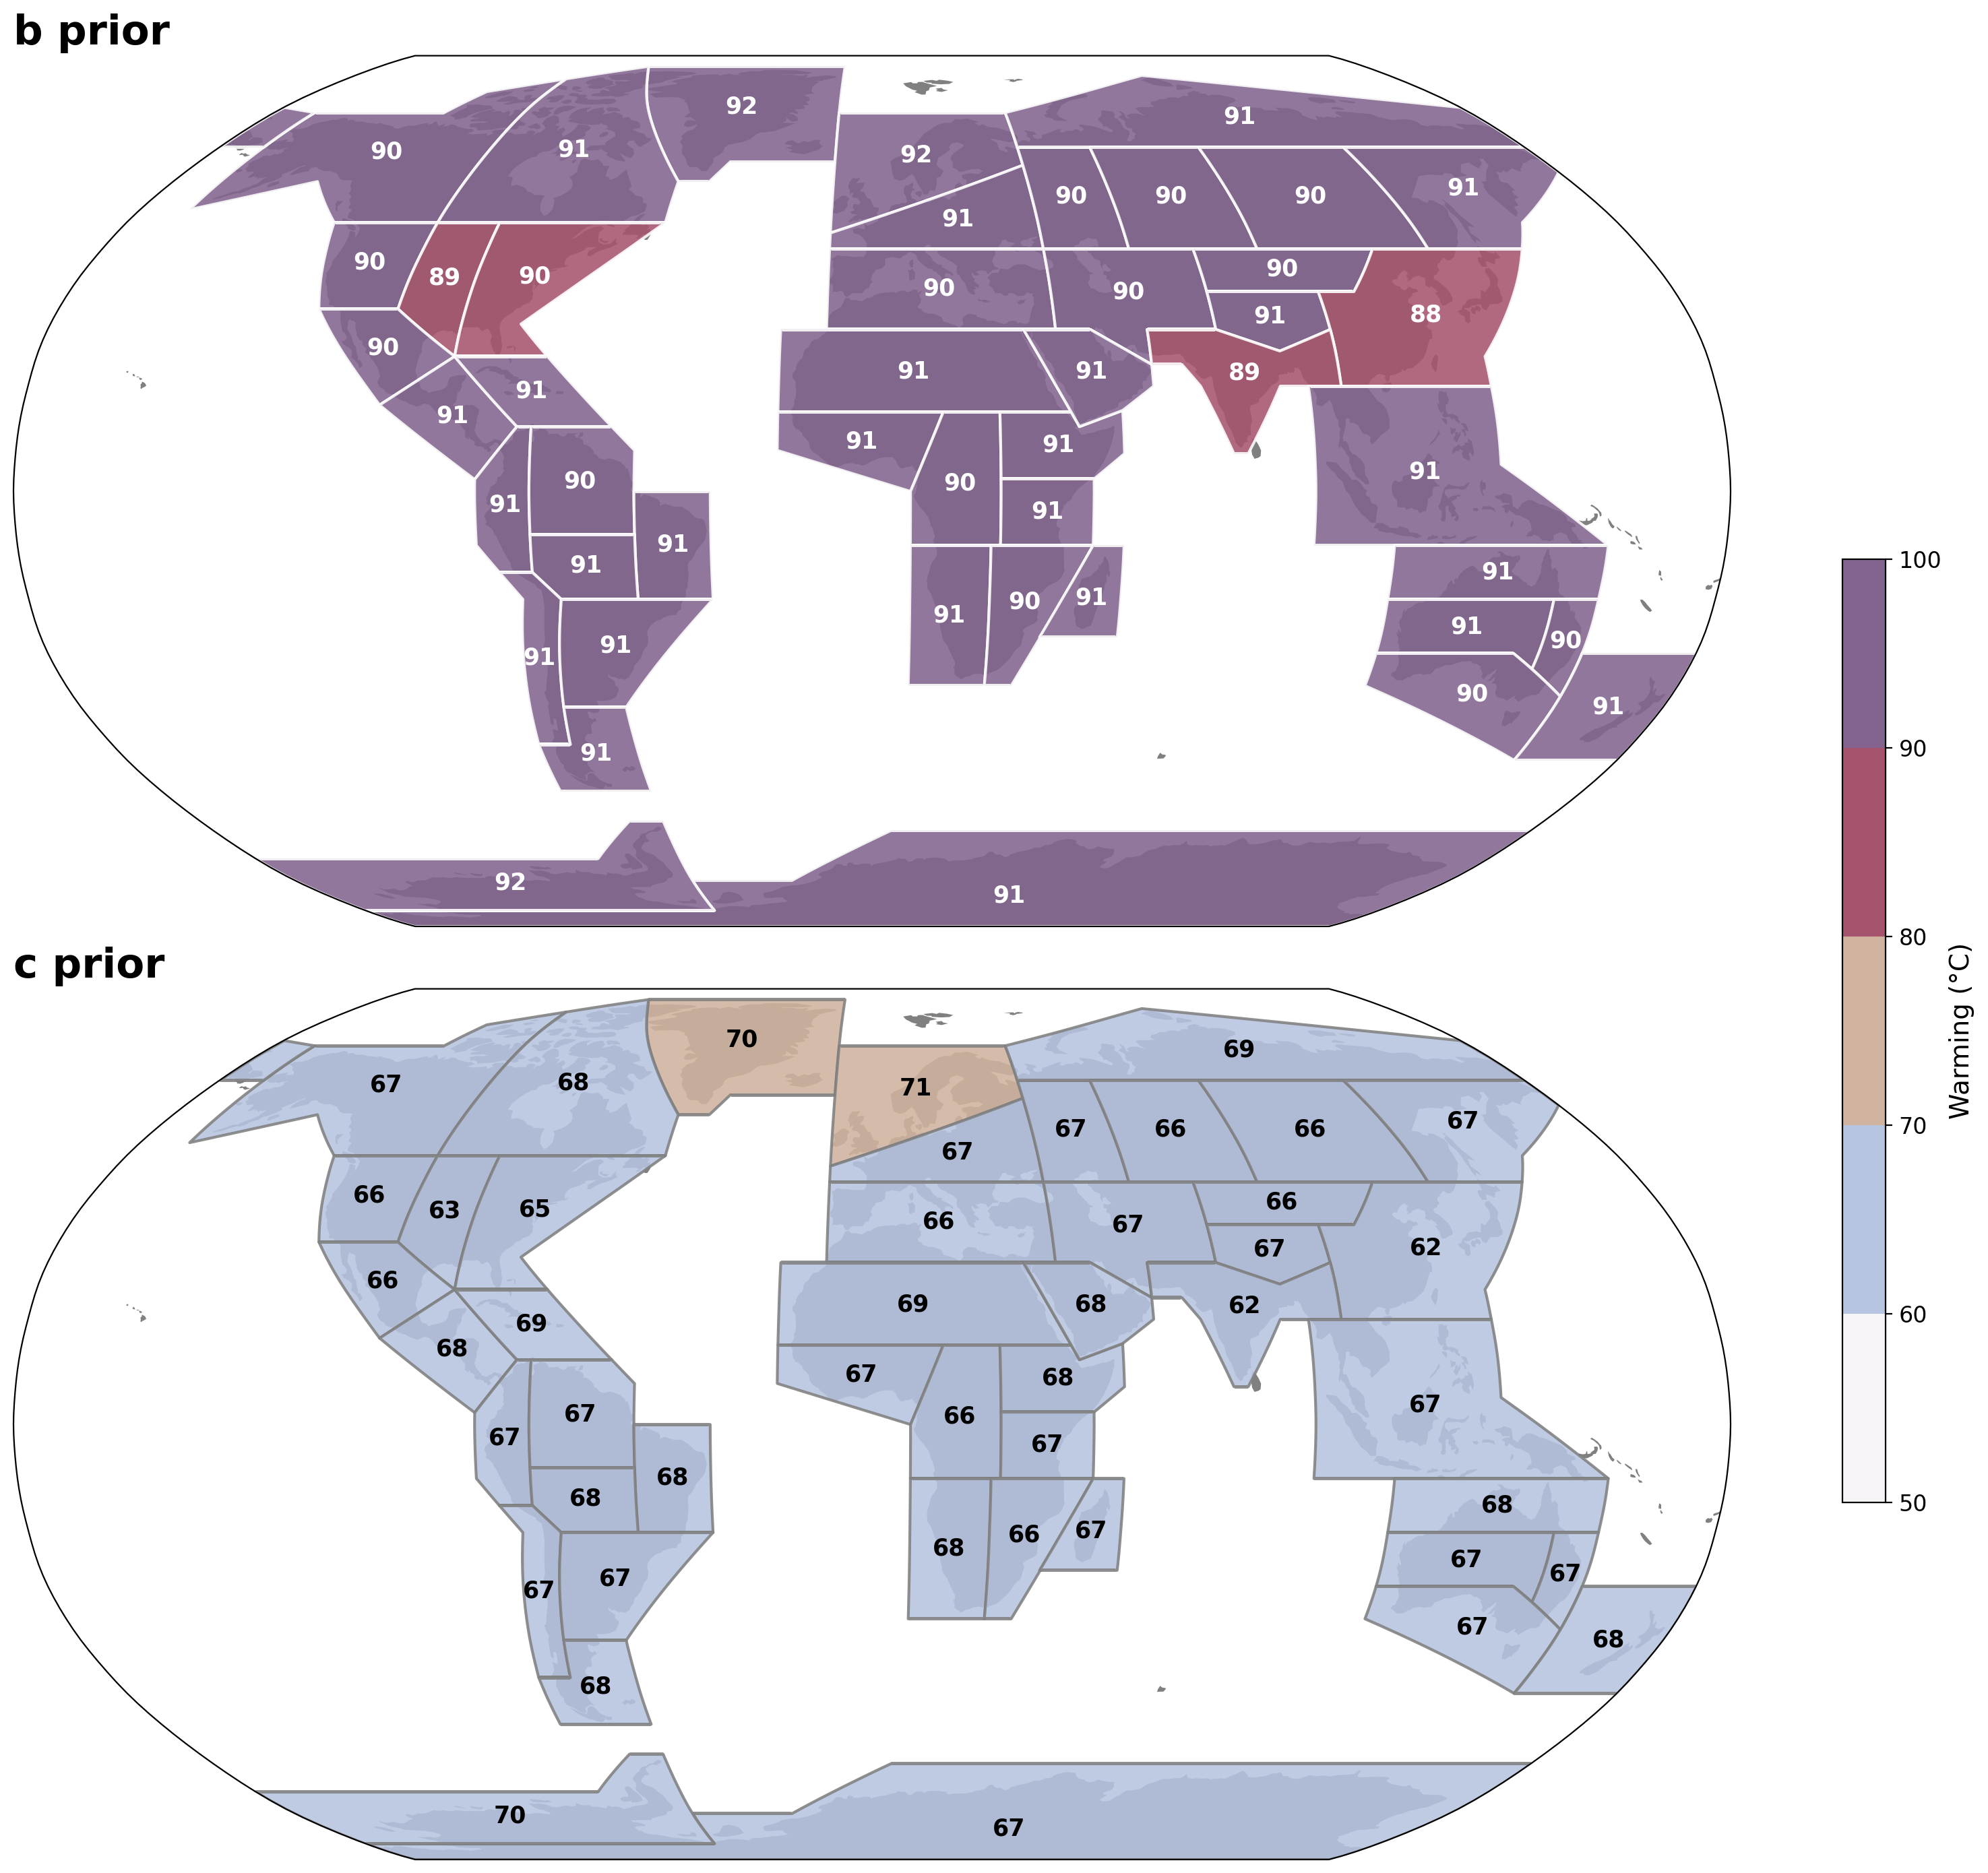

In [45]:

scheme_id = 0

for scheme_id in range(0, len(percent_nowaday_15['scheme'])):
    data_dict = {
        "b": percent_nowaday_15.isel(region = slice(0,46)).sel(quantile = 'mean').isel(scheme = scheme_id),     # existing data
        "c": percent_nowaday_2.isel(region = slice(0,46)).sel(quantile = 'mean').isel(scheme = scheme_id)    # add your second data array here
    }

    # global_15 = 91.6
    # global_2 = 69.9

    # global_values = {
    #     "b": None,
    #     "c": None
    # }

    # ---- Plot 2 panels ----
    fig, axes = plt.subplots(2, 1, figsize=(16, 14), subplot_kw={'projection': ccrs.Robinson()}, dpi=200)

    for ax, (label, data) in zip(axes, data_dict.items()):
        plot_panel(ax, data, f"{label} " + percent_nowaday_15.isel(scheme = scheme_id)['scheme'].values, cmap_percent, norm2, decimals = 0, global_value=None, unit = '%')

    # ---- Shared colorbar ----
    sm = mpl.cm.ScalarMappable(cmap=cmap_percent, norm=norm2)
    sm.set_array([])

    # [left, bottom, width, height] in figure coordinates (0–1)
    cbar_ax = fig.add_axes([0.95, 0.2, 0.02, 0.5])  
    cb = fig.colorbar(sm, cax=cbar_ax)
    cb.ax.tick_params(labelsize=12)
    cb.set_label("Warming (°C)", fontsize=14)

    plt.tight_layout()
    plt.show()
